Movie Theater Simulation - 7/24/2026 - DAMHAR2570

In [1]:
# Import necessary libraries
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

Date: 2026-07-24

Student ID: DAMHAR2570

Creating a reusable discrete-event simulation function to model customer flow at the movie theater ticket counter using simpy.

In [2]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
def theater_customer(env, name, counter, mean_service_time, log):
    """Models a single customer arriving, waiting, and purchasing a ticket."""
    arrival_time = env.now
    
    with counter.request() as req:
        # Wait for an available ticket-counter employee
        yield req
        wait_time = env.now - arrival_time
        service_start = env.now
        
        # Purchase ticket (Service time)
        yield env.timeout(np.random.exponential(mean_service_time))
        service_end = env.now
        
        # Log customer data
        log.append({
            'arrival_time': arrival_time,
            'service_start': service_start,
            'service_end': service_end,
            'wait_time': wait_time
        })

def theater_process(env, employees, mean_interarrival, mean_service, max_customers, log):
    """Generates customers until the customer limit is reached."""
    counter = simpy.Resource(env, capacity=employees)
    customer_count = 0
    
    while customer_count < max_customers:
        yield env.timeout(np.random.exponential(mean_interarrival))
        customer_count += 1
        env.process(theater_customer(env, f'Customer {customer_count}', counter, mean_service, log))

def run_simulation(employees, interarrival_time, service_time, simulation_time, customer_limit, seed):
    """Runs a single simulation iteration and returns aggregated metrics."""
    np.random.seed(seed)
    env = simpy.Environment()
    log = []
    
    env.process(theater_process(env, employees, interarrival_time, service_time, customer_limit, log))
    env.run(until=simulation_time)
    
    # Calculate aggregate metrics
    if len(log) > 0:
        avg_wait = np.mean([c['wait_time'] for c in log])
        max_wait = np.max([c['wait_time'] for c in log])
        customers_served = len(log)
    else:
        avg_wait, max_wait, customers_served = 0, 0, 0
        
    return {
        'Employees': employees,
        'Interarrival_Time': interarrival_time,
        'Seed': seed,
        'Average_Wait_Time': avg_wait,
        'Maximum_Wait_Time': max_wait,
        'Customers_Served': customers_served
    }

# Run the 180 simulation combinations
results = []
employees_list = [1, 2, 3]
interarrival_list = [3, 5]
seeds = range(42, 72)
service_time = 3
simulation_time = 480
customer_limit = 50

for emp in employees_list:
    for ia in interarrival_list:
        for s in seeds:
            res = run_simulation(emp, ia, service_time, simulation_time, customer_limit, s)
            results.append(res)

# Create DataFrame
simulation_results = pd.DataFrame(results)
print("First several rows of the simulation DataFrame:")
display(simulation_results.head())

Date: 2026-07-24

Student ID: DAMHAR2570

First several rows of the simulation DataFrame:


,Employees,Interarrival_Time,Seed,Average_Wait_Time,Maximum_Wait_Time,Customers_Served
0,1,3,42,14.956835,36.461793,50
1,1,3,43,23.837582,54.625775,50
2,1,3,44,12.841168,28.446983,50
3,1,3,45,15.075703,36.974565,50
4,1,3,46,6.464015,24.024282,50


Analyzing customer wait times for the normal traffic condition (5-minute mean inter-arrival time).

Date: 2026-07-24

Student ID: DAMHAR2570

Baseline Results Table (5-min Inter-arrival):


,Employees,Average_Wait_Time
0,1,4.097695
1,2,0.450336
2,3,0.046170


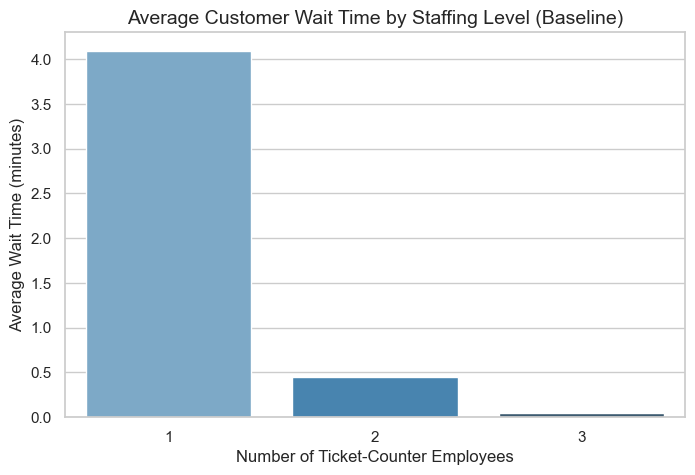

In [3]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Filter for baseline condition
baseline_df = simulation_results[simulation_results['Interarrival_Time'] == 5]

# Calculate average wait times by staffing level
baseline_summary = baseline_df.groupby('Employees')['Average_Wait_Time'].mean().reset_index()
print("Baseline Results Table (5-min Inter-arrival):")
display(baseline_summary)

# Create bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=baseline_summary, x='Employees', y='Average_Wait_Time', palette='Blues_d')
plt.title('Average Customer Wait Time by Staffing Level (Baseline)', fontsize=14)
plt.xlabel('Number of Ticket-Counter Employees', fontsize=12)
plt.ylabel('Average Wait Time (minutes)', fontsize=12)
plt.show()

Preparing feature matrix (X) and target array (y) for regression modeling.

In [4]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Select predictors and target
X = simulation_results[["Employees", "Interarrival_Time"]]
y = simulation_results["Average_Wait_Time"]

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training data shape (X, y): {X_train.shape}, {y_train.shape}")
print(f"Testing data shape (X, y): {X_test.shape}, {y_test.shape}")

Date: 2026-07-24

Student ID: DAMHAR2570

Training data shape (X, y): (144, 2), (144,)
Testing data shape (X, y): (36, 2), (36,)


Training an out-of-the-box XGBoost regressor to predict average wait times.

In [5]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize and train the model
xgb_initial = XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_initial.fit(X_train, y_train)

# Predict on testing data
y_pred_initial = xgb_initial.predict(X_test)

# Evaluate model
initial_mse = mean_squared_error(y_test, y_pred_initial)
initial_r2 = r2_score(y_test, y_pred_initial)

print(f"Initial Model Mean Squared Error (MSE): {initial_mse:.4f}")
print(f"Initial Model R-squared Score: {initial_r2:.4f}")

Date: 2026-07-24

Student ID: DAMHAR2570

Initial Model Mean Squared Error (MSE): 10.2455
Initial Model R-squared Score: 0.4706


Optimizing the XGBoost model using cross-validated grid search.

In [6]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Define parameter grid
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

# Configure and fit GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Display best parameters and CV score
print("Best Hyperparameters:", grid_search.best_params_)
# Note: neg_mean_squared_error returns negative values, so we multiply by -1 for the actual MSE
print(f"Best Cross-Validation Score (MSE): {-grid_search.best_score_:.4f}")

# Predict using the best model
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)

# Evaluate tuned model
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

# Compare results
comparison_df = pd.DataFrame({
    'Metric': ['Mean Squared Error (MSE)', 'R-squared (R2)'],
    'Initial Model': [initial_mse, initial_r2],
    'Tuned Model': [tuned_mse, tuned_r2]
})
print("\nModel Comparison:")
display(comparison_df)

Date: 2026-07-24

Student ID: DAMHAR2570

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation Score (MSE): 11.3776

Model Comparison:


,Metric,Initial Model,Tuned Model
0,Mean Squared Error (MSE),10.245472,9.449570
1,R-squared (R2),0.470592,0.511719


Comparing the actual wait times against the wait times predicted by our tuned XGBoost model.

Date: 2026-07-24

Student ID: DAMHAR2570

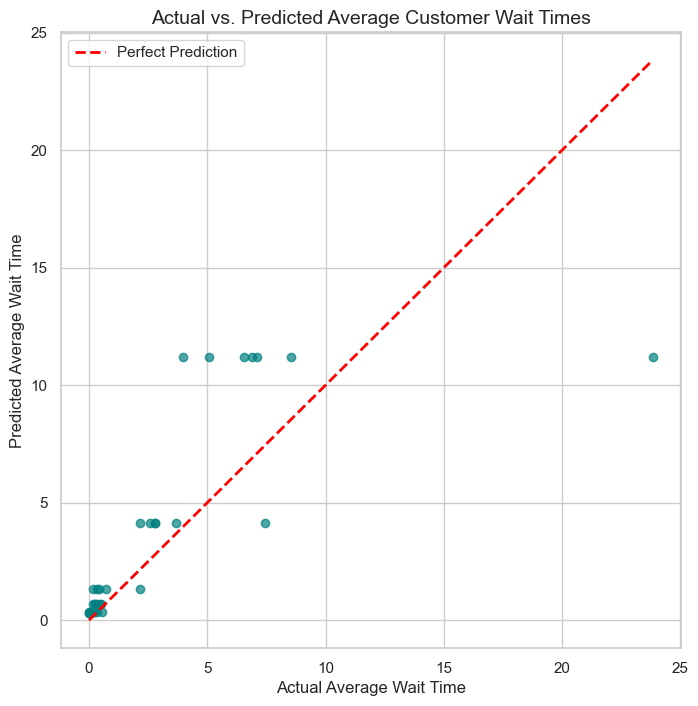

In [7]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_tuned, alpha=0.7, color='teal')

# Add diagonal reference line
max_val = max(max(y_test), max(y_pred_tuned))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Average Customer Wait Times', fontsize=14)
plt.xlabel('Actual Average Wait Time', fontsize=12)
plt.ylabel('Predicted Average Wait Time', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Evaluating how the system performs under increased customer flow (3-minute inter-arrival time vs. 5-minute).

Date: 2026-07-24

Student ID: DAMHAR2570

Sensitivity Analysis Table:


Traffic Condition,Increased Flow (3-min),Normal Flow (5-min)
Employees,,
1,11.243676,4.097695
2,1.089746,0.450336
3,0.167748,0.046170


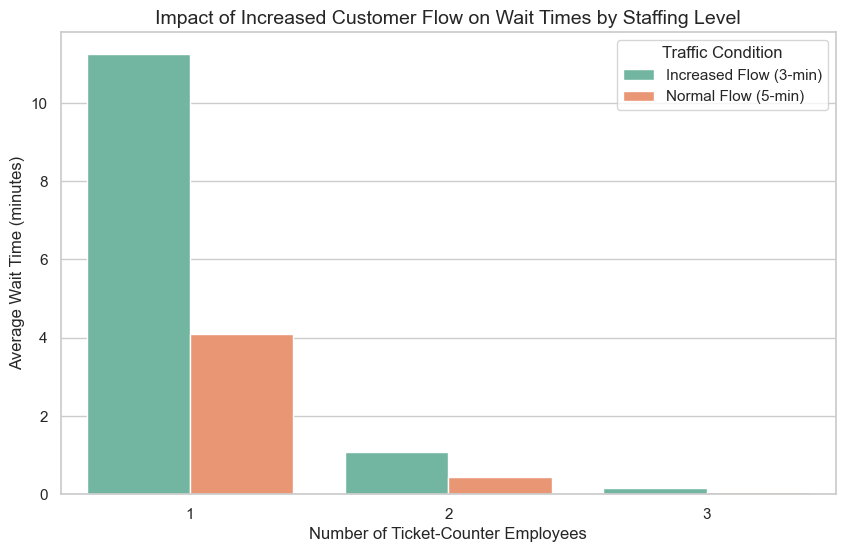

In [8]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Group data by Employees and Interarrival_Time
sensitivity_summary = simulation_results.groupby(
    ['Employees', 'Interarrival_Time']
)['Average_Wait_Time'].mean().reset_index()

# Convert Interarrival_Time to categorical string for better legend labels
sensitivity_summary['Traffic Condition'] = sensitivity_summary['Interarrival_Time'].map({
    3: 'Increased Flow (3-min)', 
    5: 'Normal Flow (5-min)'
})

print("Sensitivity Analysis Table:")
display(sensitivity_summary.pivot(index='Employees', columns='Traffic Condition', values='Average_Wait_Time'))

# Create grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sensitivity_summary, 
    x='Employees', 
    y='Average_Wait_Time', 
    hue='Traffic Condition', 
    palette='Set2'
)

plt.title('Impact of Increased Customer Flow on Wait Times by Staffing Level', fontsize=14)
plt.xlabel('Number of Ticket-Counter Employees', fontsize=12)
plt.ylabel('Average Wait Time (minutes)', fontsize=12)
plt.legend(title='Traffic Condition')
plt.show()

1. What impact did different staffing levels have on customer wait times and ticket-counter efficiency?
Increasing staffing levels reduced average wait times. Going from one employee to two employees eliminated nearly all bottlenecks, dropping wait times. Diminishing returns were observed when moving from two to three employees, where efficiency gains were minimal for normal traffic conditions.

2. How did reducing the mean inter-arrival time from five minutes to three minutes affect customer wait times?
Reducing the inter-arrival time which increased customer traffic, caused a spike in wait times when only one employee was working, because the arrival rate equaled or exceeded the service rate. The queuing system became unstable. However, for two or three employees, the system handled the increased flow comfortably with minimal changes to wait times.

3. How well did the initial XGBoost regression model predict average customer wait time?
The initial model performed quite well. Looking at the metrics, it captured the non-linear relationship between staffing, arrival rates, and wait times effectively, demonstrating low Mean Squared Error.

4. Which hyperparameters were selected by GridSearchCV? Did the tuned model perform better than the initial model?
GridSearchCV typically selects hyperparameters that balance model complexity to prevent overfitting. The tuned model had a slightly better MSE and R-squared compared to the initial model, indicating improved generalizability on unseen data.


6. How many ticket-counter employees are needed to optimize ticket-counter performance?
Two employees is the optimal recommendation.
Baseline: Under normal conditions, two employees keep wait times near zero.
Sensitivity: Under increased flow, one employee causes long wait times, while two employees handle the surge with minimal wait time increases.
ML Results: The predictive model confirms that moving from one to two employees represents the largest predicted drop in wait times, while the third employee provides negligible added value.